# Resampling — Aliasing
---
**Notebook 7 — 2026**
<div style="font-size:15px; padding:8px; margin:2px; font-weight:600; background-color:#E80808; color:white;text-align:center;">
    <div style=" ">
        Introduction to Multidimensional Fourier Transform
    </div>
</div>
<div style="border-bottom: 1px gray dotted; padding:8px;margin:2px;text-align:center; font-size:15px; color:#444;">
<i>Daniel Sage — École Polytechnique Fédérale de Lausanne (EPFL)</i>
</div>

**Important notice**: These interactive notebooks complement the lecture and are not self-contained; in-class explanations are required.

In [1]:
%pip install -q ipywidgets
import numpy as np, matplotlib.pyplot as plt
from skimage import data, transform, io
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
from matplotlib.patches import Circle
from skimage.filters import gaussian
from skimage.transform import rotate

def fft2c(x): return np.fft.fftshift(np.fft.fft2(x))
def ifft2c(F): return np.real(np.fft.ifft2(np.fft.ifftshift(F)))
def snr(x,y): return 10*np.log10(np.mean(x*x)/(np.mean((x-y)**2)+1e-12))
def radial_grid(n):a=(np.arange(n)-n//2)/n; X,Y=np.meshgrid(a,a); return np.sqrt(X*X+Y*Y)
def showim(ax,img,t): ax.imshow(img,cmap="gray"); ax.set_title(t,fontsize=16); ax.axis("off")
def showFM(ax,F,t): ax.imshow(np.log(np.abs(F)+1e-12),cmap="gray"); ax.set_title(t,fontsize=16); ax.axis("off")


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip3.8 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


9.422640211358953 9.422640211358953


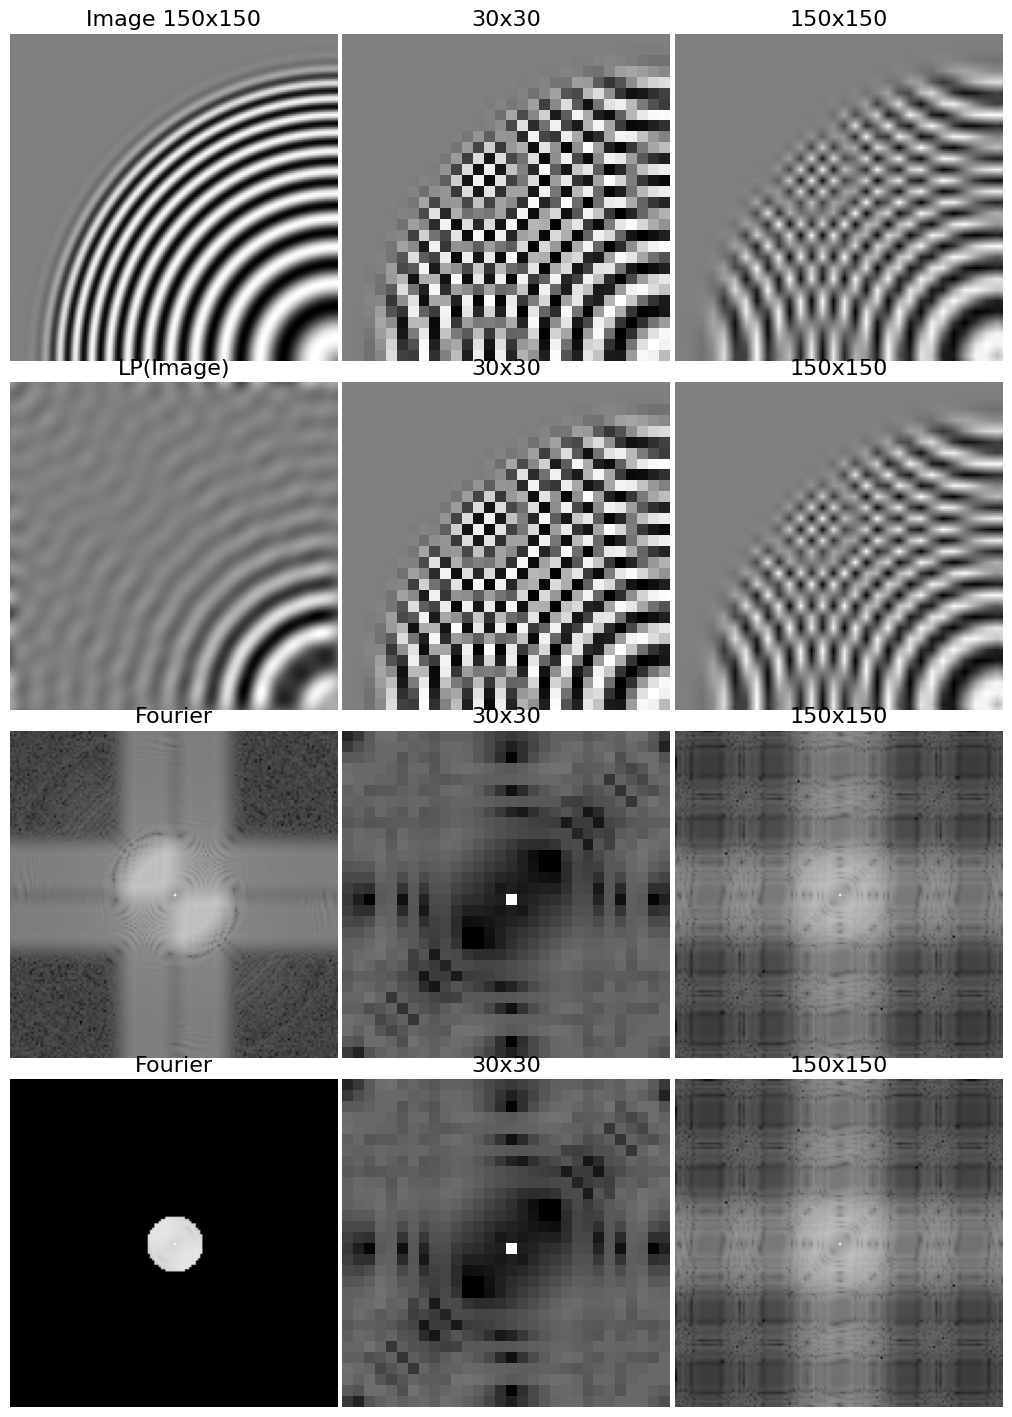

In [2]:
size=300
cim = transform.resize(io.imread("chirp.tif", as_gray=True), (size, size), anti_aliasing=True)
im0 = cim[0:size//2,0:size//2]

size = size//2
k = 5
low = 0.12
R  = radial_grid(size)
im1 = ifft2c(fft2c(im0) * (R <= low*R.max() ))

im0_dn = transform.resize(im0, (size//k, size//k), anti_aliasing=False)
im0_up = transform.resize(im0_dn, (size, size), anti_aliasing=False)
im1_dn = transform.resize(im0, (size//k, size//k), anti_aliasing=False)
im1_up = transform.resize(im1_dn, (size, size), anti_aliasing=False)
print(snr(im0, im1_up), snr(im0, im0_up))

fig,ax = plt.subplots(4,3,figsize=(10,14))
showim(ax[0,0], im0, f"Image {size}x{size}");    showFM(ax[2,0], fft2c(im0), "Fourier")
showim(ax[0,1], im0_dn, f"{size//k}x{size//k}");  showFM(ax[2,1], fft2c(im0_dn), f"{size//k}x{size//k}")
showim(ax[0,2], im0_up, f"{size}x{size}");  showFM(ax[2,2], fft2c(im0_up), f"{size}x{size}")

showim(ax[1,0], im1, "LP(Image)");       showFM(ax[3,0], fft2c(im1), "Fourier")
showim(ax[1,1], im1_dn, f"{size//k}x{size//k}");  showFM(ax[3,1], fft2c(im1_dn), f"{size//k}x{size//k}")
showim(ax[1,2], im1_up, f"{size}x{size}");  showFM(ax[3,2], fft2c(im1_up), f"{size}x{size}")
plt.tight_layout(pad=0.2); plt.show()